In [1]:
# We fit this model with the time distribution layer. Notebook carries the code for training the base model. Posthoc normalization and evaluation metrics done in the corresponding notebook 8.

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

2025-06-25 13:40:37.892719: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-25 13:40:37.928501: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-06-25 13:40:37.928523: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-06-25 13:40:37.929372: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-25 13:40:37.935384: I tensorflow/core/platform/cpu_feature_guar

In [3]:
# We need to locate the data? Need to think what we will use for training the data - the same data we used for training the seq-2-seq model? At least the input features part there

In [4]:
tf.config.list_physical_devices("GPU")

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [5]:
# location of the data? Input features
all_train_path = "seq_2_seq_train_data"

In [6]:
# all contents here?
os.listdir(all_train_path)

['block_0101_extracted_input_features.npy',
 'block_0101_extracted_target_features.npy',
 'block_0301_extracted_target_features.npy',
 'block_0102_extracted_input_features.npy',
 'block_0203_extracted_target_features.npy',
 'block_0301_extracted_input_features.npy',
 'block_0203_extracted_input_features.npy',
 'block_0102_extracted_target_features.npy']

In [7]:
# we only need the feature matrices
all_train_features_names = [file for file in os.listdir(all_train_path) if file.split(".")[0][-14:] == "input_features"]

In [8]:
all_train_features_names.sort()

In [9]:
all_train_features_names

['block_0101_extracted_input_features.npy',
 'block_0102_extracted_input_features.npy',
 'block_0203_extracted_input_features.npy',
 'block_0301_extracted_input_features.npy']

In [10]:
# load the feature files
all_train_feature_matrices = [np.load(os.path.join(all_train_path, file_name)) for file_name in all_train_features_names]

In [11]:
# stack all these together
all_train_features = np.vstack(all_train_feature_matrices)

In [12]:
all_train_features.shape

(3640, 13, 32)

In [13]:
# Also load the validation features?
all_val_path = "seq_2_seq_valid_data"

In [14]:
os.listdir(all_val_path)

['block_0204_extracted_input_features.npy',
 'block_0204_extracted_target_features.npy']

In [15]:
all_valid_features = np.load(os.path.join(all_val_path, "block_0204_extracted_input_features.npy"))

In [16]:
all_valid_features.shape

(910, 13, 32)

In [17]:
# Okay, where are the stacked densities?
all_target_density_paths = "stacked_densities"

In [18]:
os.listdir(all_target_density_paths)

['stacked_densities_block_0104.npy',
 'stacked_densities_block_0101.npy',
 'stacked_densities_block_0103.npy',
 'stacked_densities_block_0306.npy',
 'stacked_densities_block_0302.npy',
 'stacked_densities_block_0205.npy',
 'stacked_densities_block_0304.npy',
 'stacked_densities_block_0303.npy',
 'stacked_densities_block_0201.npy',
 'stacked_densities_block_0102.npy',
 'stacked_densities_block_0206.npy',
 'stacked_densities_block_0204.npy',
 'stacked_densities_block_0203.npy',
 'stacked_densities_block_0106.npy',
 'stacked_densities_block_0105.npy',
 'stacked_densities_block_0301.npy',
 'stacked_densities_block_0202.npy',
 'stacked_densities_block_0305.npy']

In [19]:
train_blocks = ["0101", "0102", "0203", "0301"]

In [20]:
train_density_files = [file for file in os.listdir(all_target_density_paths) if file.split(".")[0][-4:] in train_blocks]
train_density_files.sort()

In [21]:
train_density_files

['stacked_densities_block_0101.npy',
 'stacked_densities_block_0102.npy',
 'stacked_densities_block_0203.npy',
 'stacked_densities_block_0301.npy']

In [22]:
# load the train densities
all_train_density_vectors = [np.load(os.path.join(all_target_density_paths, file_name)) for file_name in train_density_files]

In [23]:
all_train_density_vectors[0].shape

(910, 7)

In [24]:
# stack all these densities together?
all_train_targets = np.vstack(all_train_density_vectors)

In [25]:
all_train_targets.shape

(3640, 7)

In [26]:
# load the validation densities
all_valid_targets = np.load(os.path.join(all_target_density_paths, "stacked_densities_block_0204.npy"))

In [27]:
all_valid_targets.shape

(910, 7)

Train the model - with the time distributed layer

In [28]:
# define the model
# Input shape: (batch_size, 13, 32)
input_seq = tf.keras.layers.Input(shape=(13, 32), name='input_sequence')

# Encoder LSTM
encoder_output, state_h, state_c = tf.keras.layers.LSTM(64, return_state=True, name='encoder_lstm')(input_seq)
encoder_states = [state_h, state_c]

# Repeat context vector for each of the 7 future time points
decoder_input = tf.keras.layers.RepeatVector(7)(encoder_output)

# Decoder LSTM
decoder_lstm = tf.keras.layers.LSTM(64, return_sequences=True, name='decoder_lstm')
decoder_output = decoder_lstm(decoder_input, initial_state=encoder_states)

# Output dense layer to produce 1 value per time step
output = tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(1), name='output')(decoder_output)

# Define and compile model
model = tf.keras.Model(inputs=input_seq, outputs=output)
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

model.summary()

2025-06-25 13:40:40.042297: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 31134 MB memory:  -> device: 0, name: Tesla V100S-PCIE-32GB, pci bus id: 0000:06:00.0, compute capability: 7.0


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_sequence (InputLayer  [(None, 13, 32)]             0         []                            
 )                                                                                                
                                                                                                  
 encoder_lstm (LSTM)         [(None, 64),                 24832     ['input_sequence[0][0]']      
                              (None, 64),                                                         
                              (None, 64)]                                                         
                                                                                                  
 repeat_vector (RepeatVecto  (None, 7, 64)                0         ['encoder_lstm[0][0]']    

In [30]:
callbacks = [tf.keras.callbacks.ModelCheckpoint("models/stage2_basemodel1.keras", save_best_only=True), tf.keras.callbacks.EarlyStopping(monitor='val_loss', restore_best_weights = True, verbose=1, patience=15)]

In [31]:
opt = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(loss='mean_squared_error', optimizer=opt, metrics = ['mean_absolute_error'])

In [32]:
history = model.fit(all_train_features, all_train_targets,
          epochs = 300, callbacks = callbacks,
          validation_data = (all_valid_features, all_valid_targets), 
                       batch_size = 1000, validation_batch_size = 1000)

Epoch 1/300


2025-06-25 13:40:42.721675: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907
2025-06-25 13:40:43.122331: I external/local_xla/xla/service/service.cc:168] XLA service 0x14796c3a36f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-06-25 13:40:43.122361: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): Tesla V100S-PCIE-32GB, Compute Capability 7.0
2025-06-25 13:40:43.129305: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1750876843.235396 2373751 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


4/4 [==============================] - 3s 204ms/step - loss: 0.0414 - mean_absolute_error: 0.1351 - val_loss: 0.0308 - val_mean_absolute_error: 0.1322
Epoch 2/300
4/4 [==============================] - 0s 29ms/step - loss: 0.0335 - mean_absolute_error: 0.1041 - val_loss: 0.0203 - val_mean_absolute_error: 0.1106
Epoch 3/300
4/4 [==============================] - 0s 32ms/step - loss: 0.0292 - mean_absolute_error: 0.1255 - val_loss: 0.0134 - val_mean_absolute_error: 0.0530
Epoch 4/300
4/4 [==============================] - 0s 17ms/step - loss: 0.0243 - mean_absolute_error: 0.0702 - val_loss: 0.0162 - val_mean_absolute_error: 0.0663
Epoch 5/300
4/4 [==============================] - 0s 19ms/step - loss: 0.0238 - mean_absolute_error: 0.0695 - val_loss: 0.0144 - val_mean_absolute_error: 0.0704
Epoch 6/300
4/4 [==============================] - 0s 20ms/step - loss: 0.0237 - mean_absolute_error: 0.0936 - val_loss: 0.0135 - val_mean_absolute_error: 0.0574
Epoch 7/300
4/4 [======================

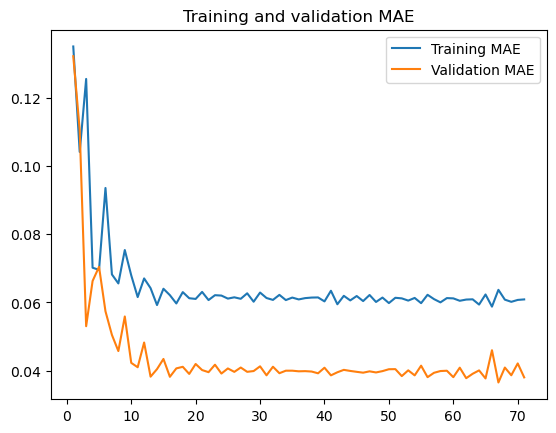

In [33]:
loss = history.history["mean_absolute_error"]
val_loss = history.history["val_mean_absolute_error"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, label="Training MAE")
plt.plot(epochs, val_loss, label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()